## MIZ test

In [1]:
# Run this in the terminal
%run ./desp-authentication.py 

Username:  ········
Password:  ········


Token successfully written to /home/jovyan/.polytopeapirc


# Requirements
To run this notebook install the following:
* pip install earthkit-data
* pip install earthkit-plots
* pip install earthkit-regrid  (Optional for spectral variables)
* pip install cf-units         (Optional for unit conversion in maps)

If you do not have eccodes installed please install eccodes using conda as it is a dependency of earthkit, or install earthkit via conda

* conda install eccodes -c conda-forge
* conda install earthkit-data -c conda-forge

In [2]:
import earthkit.data
import earthkit.plots
import earthkit.regrid

In [3]:
# Ice data
request = {
    "activity": "ScenarioMIP",
    "class": "d1",
    "dataset": "climate-dt",
    "date": "20210315/20210915",
    "experiment": "SSP3-7.0",
    "expver": "0001",
    "generation": "1",
    "levtype": "o2d",
    "model": "IFS-NEMO",
    "param": "263001/263000",
    "realization": "1",
    "resolution": "high",
    "stream": "clte",
    "time": "0000",
    "type": "fc",
}

In [14]:
# Ice data
request = {
    'class': 'ng',
    'activity': 'story-nudging',
    'experiment': 'cont',
    'expver': '0001',
    'model': 'IFS-FESOM',
    'generation': '1',
    'realization': '1',
    'resolution': 'high',
    'date': '20190201/to/20190201',
    'time': '0000',
    'stream': 'clte',
    'type': 'fc',
    'levtype': 'o2d',
    'param': '263001/263000'
}

In [16]:
# Ice data
request = {
    "activity": "ScenarioMIP",
    "class": "d1",
    "dataset": "climate-dt",
    "date": "20210315/20210915",
    "experiment": "SSP3-7.0",
    "expver": "0001",
    "generation": "1",
    "levtype": "o2d",
    "model": "ICON",
    "param": "263001/263000",
    "realization": "1",
    "resolution": "high",
    "stream": "clte",
    "time": "0000",
    "type": "fc",
}

In [4]:
src = request['model']
src

'IFS-NEMO'

In [43]:
#data is an earthkit streaming object but with stream=False will download data immediately 
dataICE = earthkit.data.from_source("polytope", "destination-earth", request, address="polytope.lumi.apps.dte.destination-earth.eu", stream=False)

DEBUG:polytope.api.Client.7QQ8O9:Gathered Polytope client configuration:
{'address': 'polytope.lumi.apps.dte.destination-earth.eu',
 'insecure': False,
 'key_path': PosixPath('/home/jovyan/.polytopeapirc'),
 'log_file': None,
 'log_level': 'DEBUG',
 'password': None,
 'port': None,
 'quiet': False,
 'skip_tls': False,
 'user_email': None,
 'user_key': None,
 'username': 'jovyan',
 'verbose': False}
DEBUG:polytope.api.Client.7QQ8O9:Creating Polytope client...
2025-10-16 10:16:02 - INFO - Key read from /home/jovyan/.polytopeapirc
INFO:polytope.api.Client.7QQ8O9:Key read from /home/jovyan/.polytopeapirc
2025-10-16 10:16:02 - INFO - Sending request...
{'request': 'activity: ScenarioMIP\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            'date: 20210315/20210915\n'
            'experiment: SSP3-7.0\n'
            "expver: '0001'\n"
            "generation: '1'\n"
            'levtype: o2d\n'
            'model: IFS-NEMO\n'
            'param: 263001/263000\n'
      

5dbc7442-775a-4df3-9eda-02a13076d319.grib:   0%|          | 0.00/8.63M [00:00<?, ?B/s]

DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): download-polytope.lumi.apps.dte.destination-earth.eu:443
DEBUG:urllib3.connectionpool:https://download-polytope.lumi.apps.dte.destination-earth.eu:443 "GET /default/5dbc7442-775a-4df3-9eda-02a13076d319.grib HTTP/1.1" 200 9046531


In [45]:
dataICE

GRIBReader(/tmp/tmpw8qcp6ir/url-b6804198dca624b3c3a99bcc35274b38be4b02a12812899d03d26668fdb5de78.grib)

In [46]:
dataICE.ls()

,centre,shortName,typeOfLevel,level,dataDate,dataTime,stepRange,dataType,number,gridType
0,ecmf,avg_siconc,iceTopOnWater,0,20210315,0,0-24,fc,None,healpix
1,ecmf,avg_sithick,iceLayerOnWater,0,20210315,0,0-24,fc,None,healpix
2,ecmf,avg_siconc,iceTopOnWater,0,20210915,0,0-24,fc,None,healpix
3,ecmf,avg_sithick,iceLayerOnWater,0,20210915,0,0-24,fc,None,healpix


In [47]:
data=earthkit.regrid.interpolate(dataICE, out_grid={"grid": [0.1,0.1]}, method="linear").to_xarray(engine="cfgrib")

In [48]:
data

<xarray.Dataset> Size: 104MB
Dimensions:          (time: 2, step: 1, iceTopOnWater: 1, latitude: 1801,
                      longitude: 3600, iceLayerOnWater: 1)
Coordinates:
  * time             (time) datetime64[ns] 16B 2021-03-15 2021-09-15
  * step             (step) timedelta64[ns] 8B 1 days
  * iceTopOnWater    (iceTopOnWater) float64 8B 0.0
  * latitude         (latitude) float64 14kB 90.0 89.9 89.8 ... -89.9 -90.0
  * longitude        (longitude) float64 29kB 0.0 0.1 0.2 ... 359.7 359.8 359.9
    valid_time       (time, step) datetime64[ns] 16B ...
  * iceLayerOnWater  (iceLayerOnWater) float64 8B 0.0
Data variables:
    avg_siconc       (time, step, iceTopOnWater, latitude, longitude) float32 52MB ...
    avg_sithick      (time, step, iceLayerOnWater, latitude, longitude) float32 52MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          1003
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-10-16T10:28 GRIB to CDM+CF via cfgrib-0.9.1...

In [49]:
t1 = '2021-03-15T00:00:00.000000000'
t2 = '2021-09-15T00:00:00.000000000'
sic1 = data.avg_siconc.sel(time=t1,latitude=slice(90.,30.))
sit1 = data.avg_sithick.sel(time=t1,latitude=slice(90.,30.))
sic2 = data.avg_siconc.sel(time=t2,latitude=slice(90.,30.))
sit2 = data.avg_sithick.sel(time=t2,latitude=slice(90.,30.))
sic1.to_netcdf('sic1.nc')
sic1

<xarray.DataArray 'avg_siconc' (step: 1, iceTopOnWater: 1, latitude: 601,
                                longitude: 3600)> Size: 9MB
[2163600 values with dtype=float32]
Coordinates:
    time           datetime64[ns] 8B 2021-03-15
  * step           (step) timedelta64[ns] 8B 1 days
  * iceTopOnWater  (iceTopOnWater) float64 8B 0.0
  * latitude       (latitude) float64 5kB 90.0 89.9 89.8 89.7 ... 30.2 30.1 30.0
  * longitude      (longitude) float64 29kB 0.0 0.1 0.2 ... 359.7 359.8 359.9
    valid_time     (step) datetime64[ns] 8B ...
Attributes: (12/30)
    GRIB_paramId:                             263001
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      6483600
    GRIB_typeOfLevel:                         iceTopOnWater
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avg
    ...                                       ...
    GRIB_name:                                Time-mean sea ice area fraction
    GRIB_shortName:                           avg_siconc
    GRIB_units:                               Fraction
    long_name:                                Time-mean sea ice area fraction
    units:                                    Fraction
    standard_name:                            unknown

In [50]:
str(sic2.time.values)[:10]

'2021-09-15'

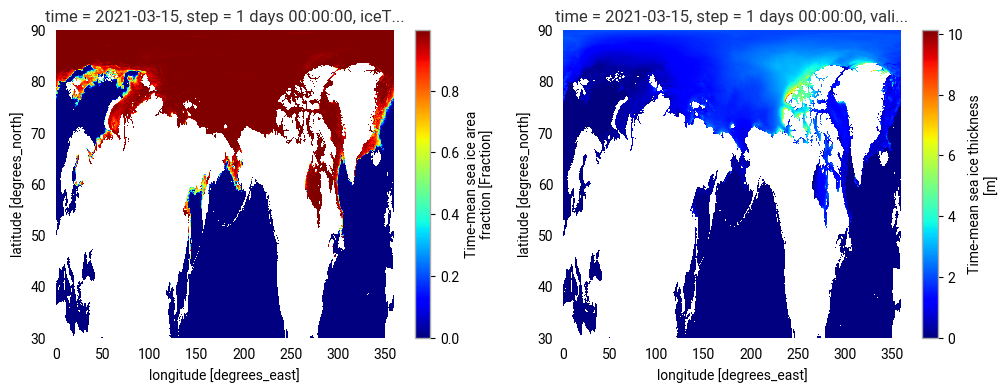

In [59]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(ncols=2, figsize=(12, 4))

sic1.plot(ax=axes[0],cmap='jet')
sit1.plot(ax=axes[1],cmap='jet')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


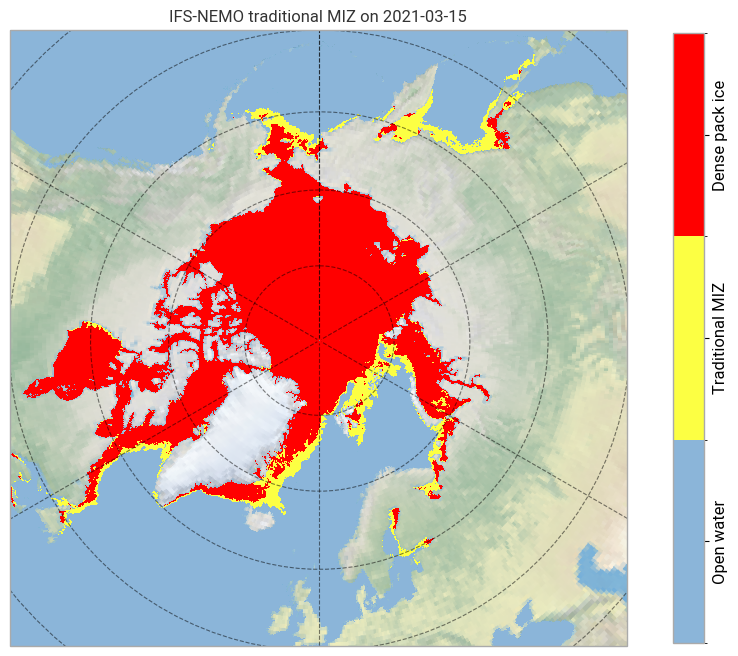

In [40]:
%load_ext autoreload
#%autoreload 2

from mod_MIZ import plot_mizt
#src = request['model']
plot_mizt(sic1,src=request['model'])

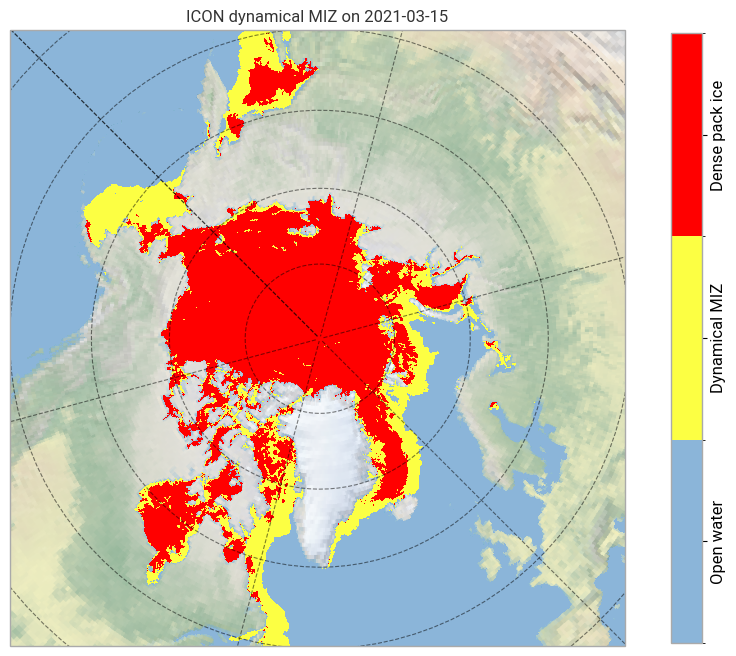

In [42]:
%reload_ext autoreload
%autoreload 2

from mod_MIZ import plot_mizd
plot_mizd(sic1,sit1,src=request['model'])

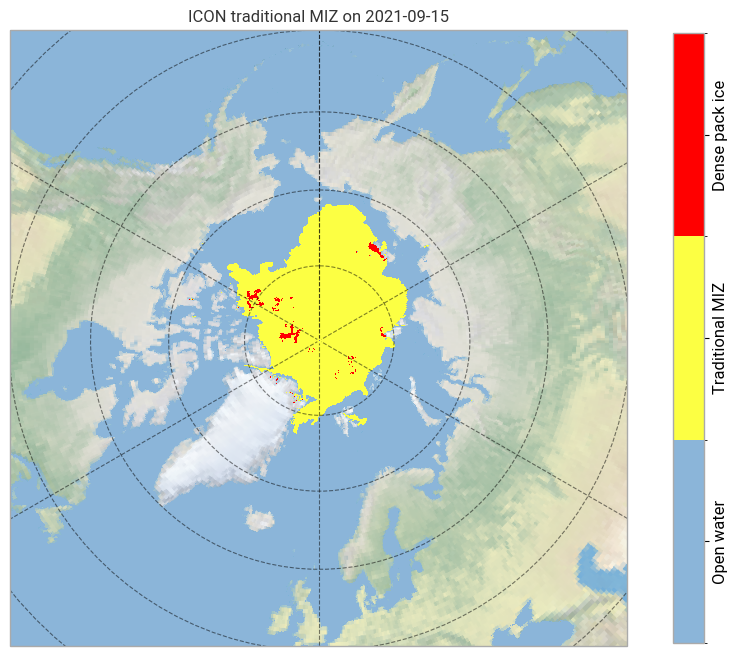

In [28]:
plot_mizt(sic2,src=src)

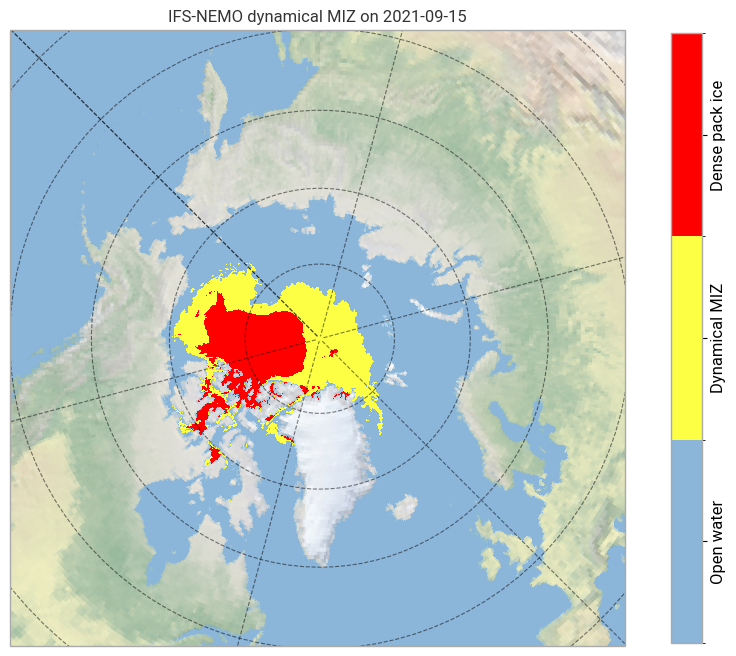

In [61]:
plot_mizd(sic2,sit2,src=request['model'])

In [45]:
%reload_ext autoreload
%autoreload 2

import get_nic_MIZ

In [46]:
get_nic_MIZ.download_nic_data('20210315')

Skipping ftp://sidads.colorado.edu/DATASETS/NOAA/G10017/north/2021/nic_miz2021074nc_pl_a.zip - already exists


In [ ]:
plot_mizt(sic,area='Barents')